# Random Testing Yahoo stuff

In [126]:
##Ignore this stuff
import pandas as pd
import numpy as np
import yfinance as yf  # to fetch historical price data
import plotly.express as px
import matplotlib.pyplot as plt

# Step 1: Data Collection
import yfinance as yf
dat = yf.Ticker("MSFT")
#(dat.info)
#print(dat.calendar)
#print(dat.analyst_price_targets)
#print(dat.quarterly_income_stmt)
#test = pd.DataFrame(dat.history(period='max'))
#df = pd.DataFrame(dat.option_chain(dat.options[0]).puts)
'''
prices = data['Adj Close']

# Step 2: Calculate Returns
returns = prices.pct_change().dropna()

# Step 3: Calculate Basic Risk Metrics
volatility = returns.std()  # standard deviation of returns
variance = returns.var()
mean_return = returns.mean()

# Example: Calculate Beta relative to S&P 500
benchmark = '^GSPC'
benchmark_data = yf.download(benchmark, start='2020-01-01', end='2023-01-01')
benchmark_returns = benchmark_data['Adj Close'].pct_change().dropna()

cov_matrix = np.cov(returns, benchmark_returns)
cov = cov_matrix[0, 1]
benchmark_var = benchmark_returns.var()
beta = cov / benchmark_var

# Step 4: Calculate Sharpe Ratio (assuming risk-free rate is 0 for simplicity)
sharpe_ratio = mean_return / volatility

print(f"Volatility (Std Dev): {volatility}")
print(f"Variance: {variance}")
print(f"Beta: {beta}")
print(f"Sharpe Ratio: {sharpe_ratio}")
'''
#df.sort_values('lastTradeDate', ascending = False).head(30)
#dat.live()
#test

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1986-03-13 00:00:00-05:00,0.054188,0.062157,0.054188,0.059500,1031788800,0.0,0.0
1986-03-14 00:00:00-05:00,0.059500,0.062688,0.059500,0.061625,308160000,0.0,0.0
1986-03-17 00:00:00-05:00,0.061625,0.063219,0.061625,0.062688,133171200,0.0,0.0
1986-03-18 00:00:00-05:00,0.062688,0.063219,0.060562,0.061093,67766400,0.0,0.0
1986-03-19 00:00:00-05:00,0.061093,0.061625,0.059500,0.060031,47894400,0.0,0.0
...,...,...,...,...,...,...,...
2025-10-28 00:00:00-04:00,550.000000,553.719971,540.770020,542.070007,29986700,0.0,0.0
2025-10-29 00:00:00-04:00,544.940002,546.270020,536.729980,541.549988,36023000,0.0,0.0
2025-10-30 00:00:00-04:00,530.479980,534.969971,522.119995,525.760010,41023100,0.0,0.0


# Actual Stuff

In [424]:
import pandas as pd
import numpy as np
import yfinance as yf  # to fetch historical price data
import plotly.express as px
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
from sklearn.decomposition import PCA
# Step 1: Data Collection
import yfinance as yf

In [513]:
class StockPortfolio:
    '''
    This class is to help us manage data regarding a given list of stock tickers
    tickList: list or string of our stock tickers
    tickerList: Dictionary of our ticker names with the yf ticker object
    timePeriod: how far we want to look back on historical data,  must be one of: 1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max ,,, defaulting to 1 year
    data: A dataframe provided by yahoo finance api that gives us the daily open, close, adjusted close prices, highs and lows, and trading volume
            information for our tickers during a specified time period
    '''
    def __init__(self, tickList):
        self.tickerList = yf.Tickers(tickList).tickers
        self.timePeriod = '1y'
        self.data = yf.download(list(self.tickerList.keys()), period = self.timePeriod, auto_adjust = False) #tickers.tickers is a dictionary of yf ticker objects with keys being the ticker names
    def getSimpleReturnHistory(self) -> pd.DataFrame:
        '''
        This method calculates the daily closing price pct changes,
        calculated by taking the difference between the kth and (k-1)th day's non-adjusted closing price
        then dividing this difference by the (k-1)th close price to find the pct change after the kth day's market close
        '''
        #data = yf.download(list(self.YfTickers.keys()), period = timePeriod, auto_adjust = False) #tickers.tickers is a dictionary of yf ticker objects with keys being the ticker names
        self.simpleReturn = self.data[('Close',)].pct_change().dropna()
        return self.simpleReturn
    def getLogReturnHistory(self) -> pd.DataFrame:
        '''
        This Method calculates the log return for each day, ln(Close Price of Today/close price of yesterday)
        '''
        self.logReturn = np.log(self.data[('Close',)]) - np.log(self.data[('Close',)].shift(1)).dropna()
        return self.logReturn
    def change_timePeriod(self, newTimePeriod: str) -> None:
        '''
        This method changes the time period for the historical data we want to look at
        '''
        self.timePeriod = newTimePeriod
        self.data = yf.download(list(self.tickerList.keys()), period = self.timePeriod, auto_adjust = False) #tickers.tickers is a dictionary of yf ticker objects with keys being the ticker names
    def simpleReturnVolatility(self) -> float:
        '''
        We Actually don't need this
        '''
        mean = self.getSimpleReturnHistory().mean()
        std = self.getSimpleReturnHistory().std()
        return std 
    def logReturnVolatility(self) -> float:
        '''
        I don't think we need this either
        '''
        mean = self.getLogReturnHistory().mean()
        std = self.getLogReturnHistory().std()
        return std

In [459]:
test = StockPortfolio(['MSFT', 'AAPL','GOOG','UNH','NVDA','KO','BA','MDT','MCD','SO','NKE'])

[*********************100%***********************]  11 of 11 completed


In [460]:
test.simpleReturnVolatility()

Ticker
AAPL    0.020589
BA      0.023479
GOOG    0.020344
KO      0.011149
MCD     0.011291
MDT     0.013556
MSFT    0.015271
NKE     0.025014
NVDA    0.031211
SO      0.011091
UNH     0.030719
dtype: float64

In [461]:
test.logReturnVolatility()

Ticker
AAPL    0.020407
BA      0.023395
GOOG    0.020263
KO      0.011129
MCD     0.011293
MDT     0.013628
MSFT    0.015129
NKE     0.024939
NVDA    0.031336
SO      0.011104
UNH     0.032069
dtype: float64

In [478]:
test.change_timePeriod('6mo')

[*********************100%***********************]  11 of 11 completed


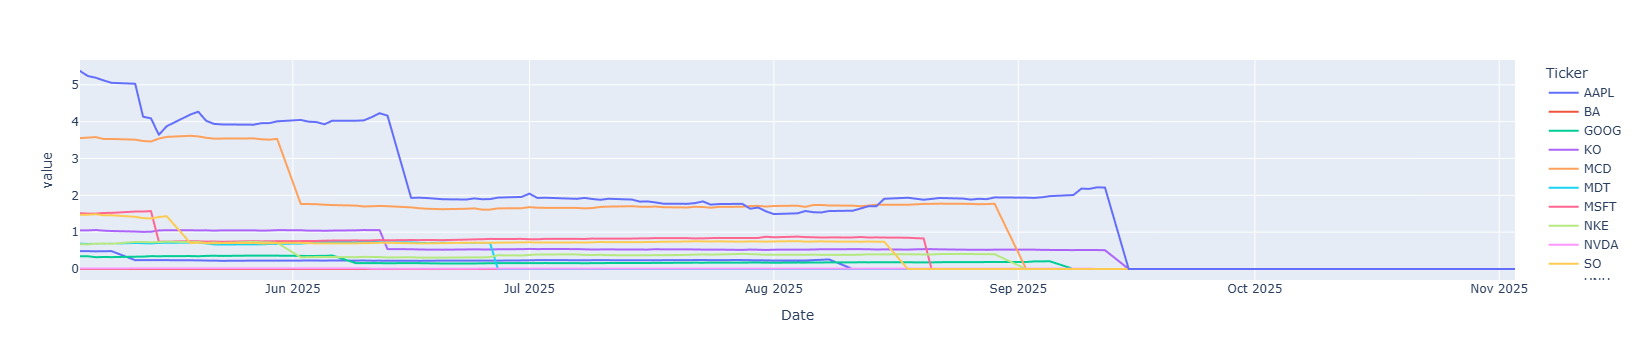

In [479]:
#Wanted to see how drastic the different in the adjusted and actual close price is
df = test.data[('Close',)]-test.data[('Adj Close',)]
fig = px.line(df, x = df.index, y = df.columns)
fig.show()

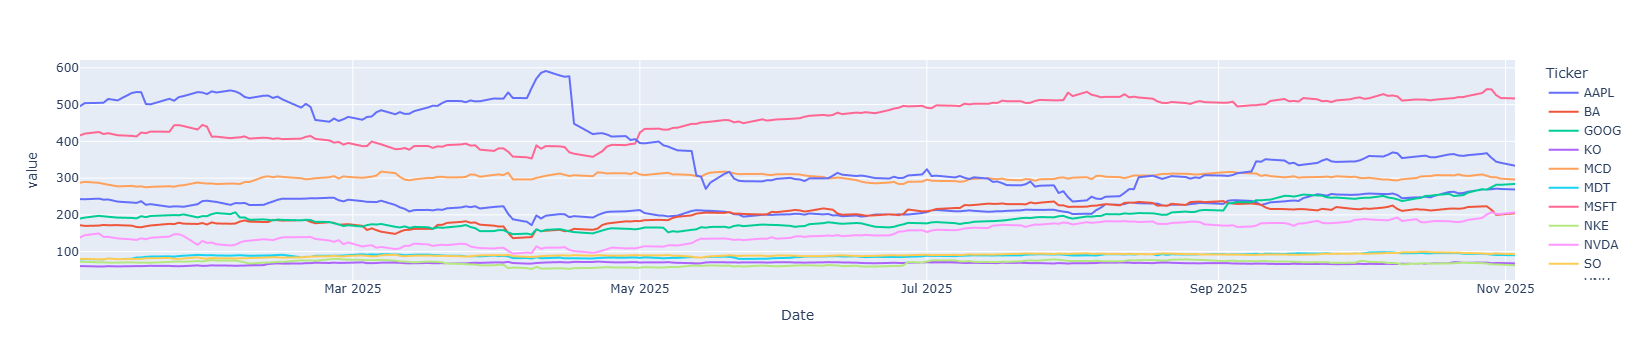

In [515]:
df = test.data[('Adj Close',)]
fig = px.line(df, x = df.index, y = df.columns)
fig.show()

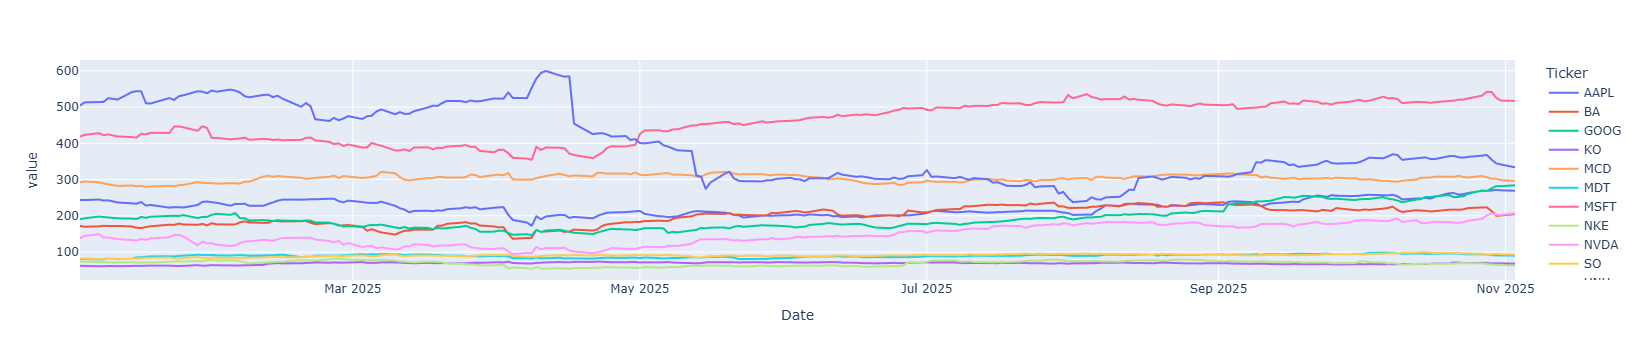

In [514]:
df = test.data[('Close',)]
fig = px.line(df, x = df.index, y = df.columns)
fig.show()

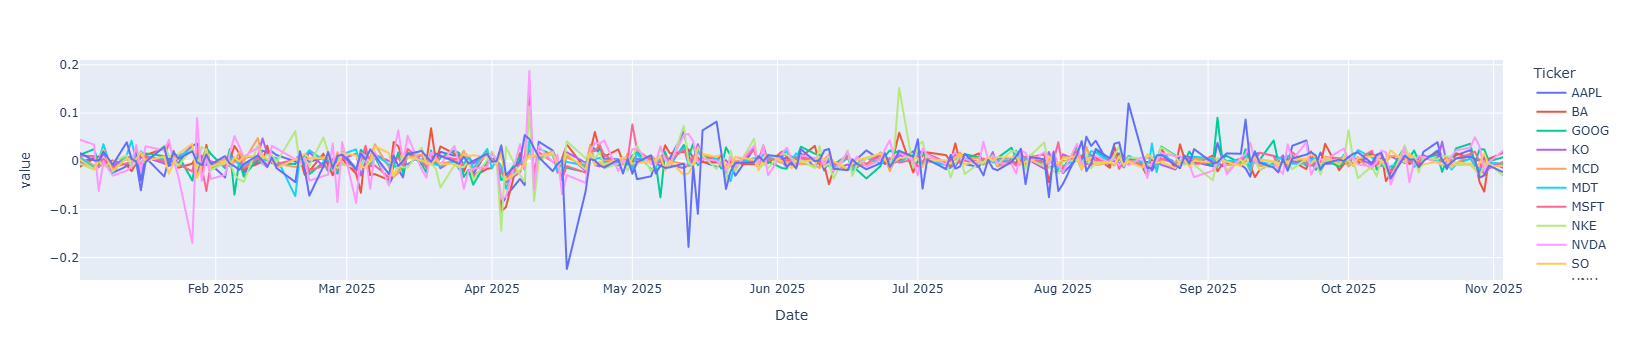

In [516]:
df = test.getSimpleReturnHistory()
fig = px.line(df, x = df.index, y = df.columns)
fig.show()

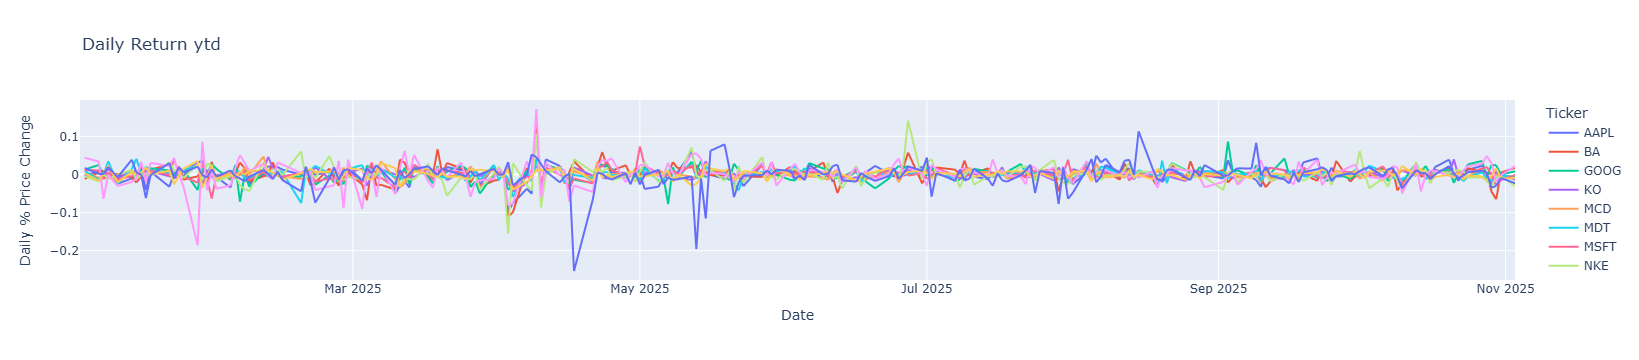

In [511]:
df = test.getLogReturnHistory()
fig = px.line(df, x = df.index, y = df.columns, title = f'Daily Return {test.timePeriod}')
fig.update_layout(yaxis_title="Daily % Price Change")
fig.show()

In [502]:
test.change_timePeriod('ytd')
returns = test.getLogReturnHistory().dropna()
summary_stats = returns.describe().T
summary_stats['skew'] = returns.skew()
summary_stats['kurtosis'] = returns.kurtosis()
corr_matrix = returns.corr()
cov_matrix = returns.cov()
summary_stats

[*********************100%***********************]  11 of 11 completed


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
Ticker,,,,,,,,,,
AAPL,209.0,0.000471,0.021794,-0.097013,-0.007422,0.000786,0.008996,0.142617,0.670884,10.400692
BA,209.0,0.000833,0.024085,-0.110608,-0.007326,0.001216,0.012473,0.143010,0.092059,8.724964
GOOG,209.0,0.001909,0.020217,-0.078027,-0.007425,0.002002,0.013126,0.094206,0.081304,4.201261
KO,209.0,0.000452,0.011494,-0.045427,-0.007529,-0.000428,0.007509,0.046168,0.282001,2.288292
MCD,209.0,0.000063,0.011667,-0.058751,-0.007122,0.000221,0.006361,0.046863,-0.083123,3.927267
MDT,209.0,0.000561,0.014159,-0.075393,-0.006401,0.001245,0.007884,0.041433,-0.919967,5.183600
MSFT,209.0,0.001011,0.015650,-0.063802,-0.005919,0.000763,0.006120,0.096525,1.182537,9.314138
NKE,209.0,-0.000775,0.026487,-0.155948,-0.012705,-0.001795,0.010477,0.141415,0.110415,10.164769
NVDA,209.0,0.001927,0.032732,-0.185946,-0.009714,0.003531,0.018992,0.171621,-0.607645,8.098848


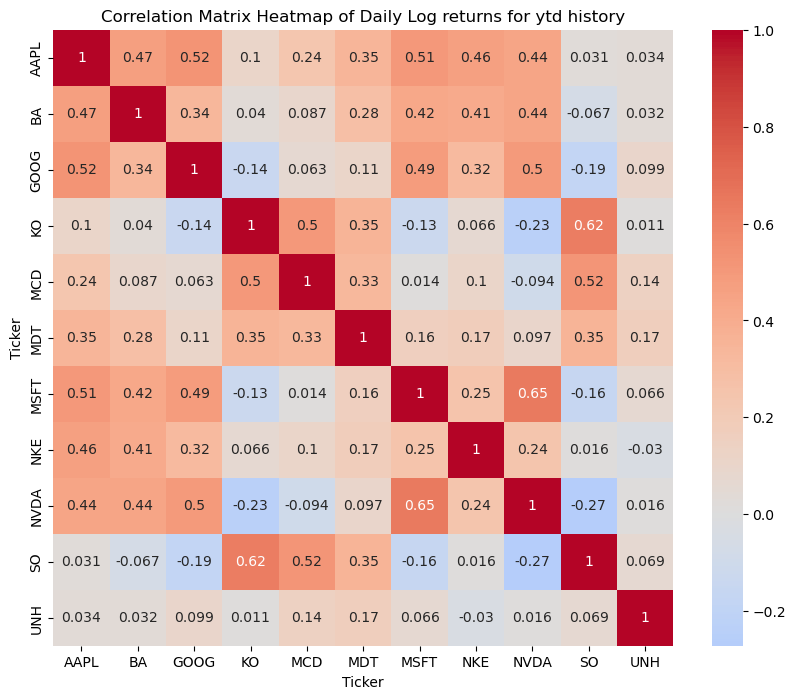

In [503]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title(f'Correlation Matrix Heatmap of Daily Log returns for {test.timePeriod} history' )
plt.show()

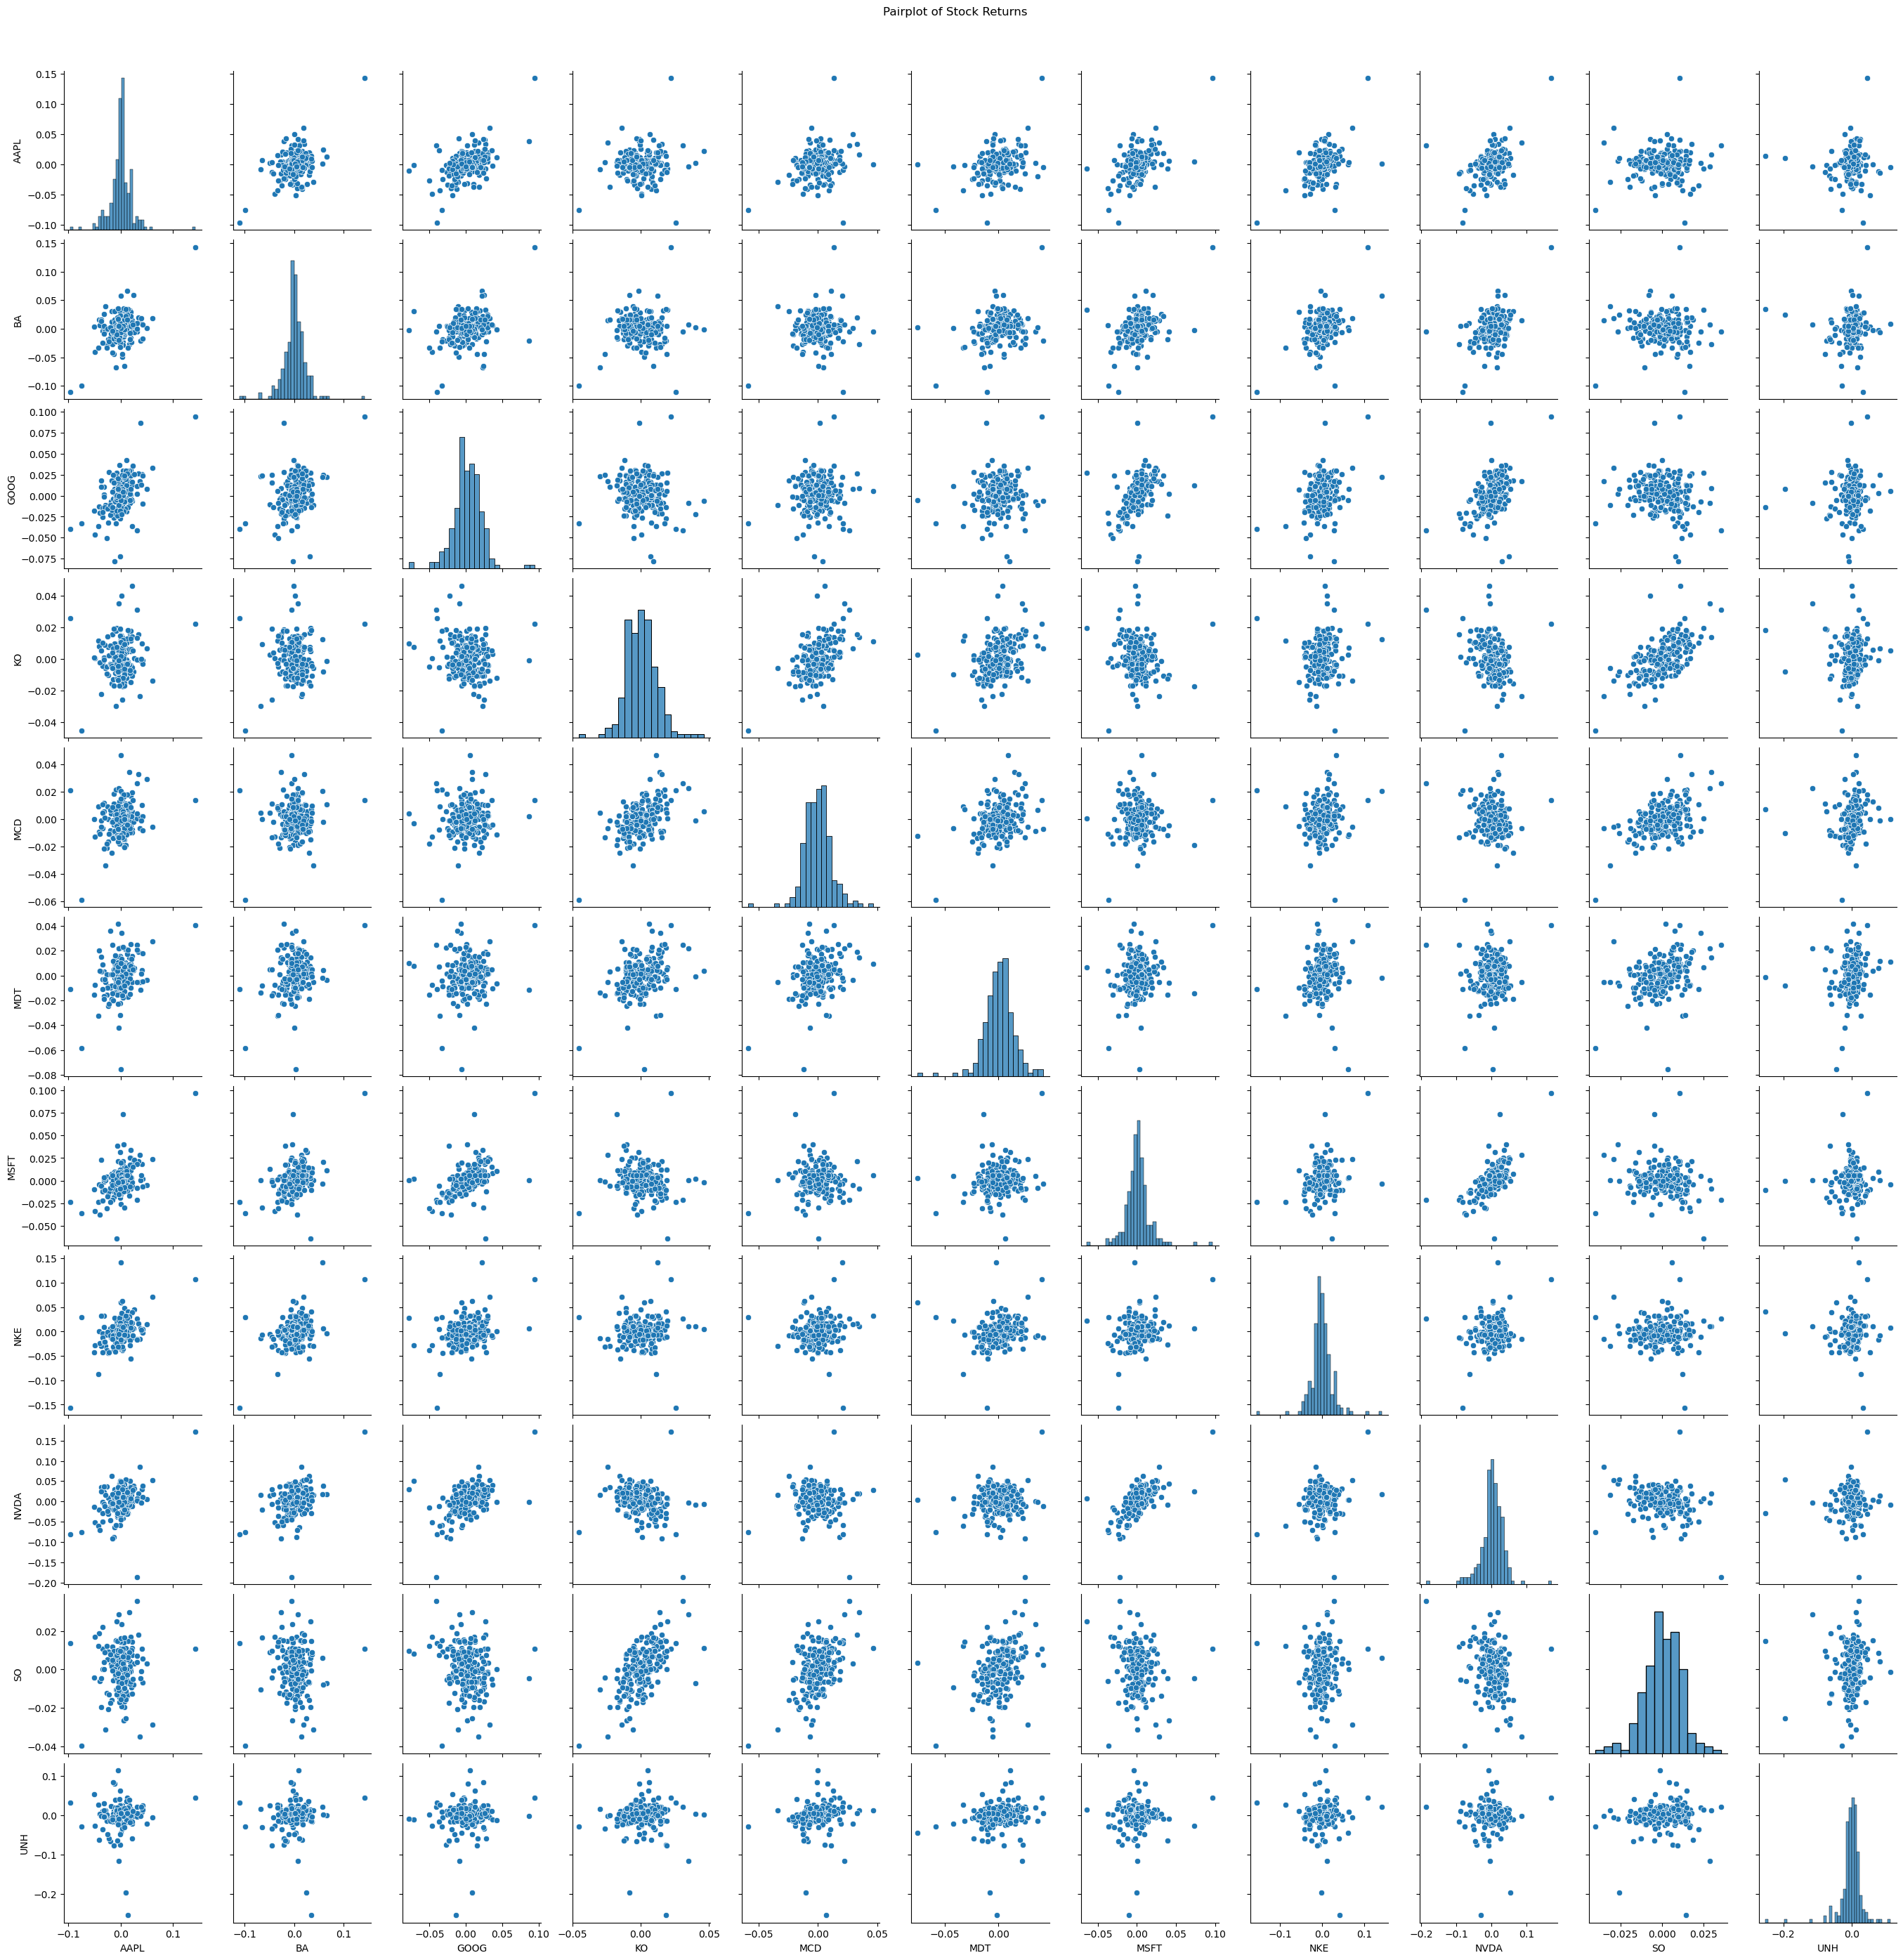

In [504]:
sns.pairplot(returns)
plt.suptitle('Pairplot of Stock Returns', y=1.02)
plt.show()

In [487]:
regression_results = {}
for stock in returns.columns:
    y = returns[stock]
    X = returns.drop(columns=stock)
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    regression_results[stock] = model.summary()

In [488]:
pca = PCA(n_components=11)
pca.fit(returns)
pca_components = pca.components_
explained_variance = pca.explained_variance_ratio_
explained_variance

array([0.33128441, 0.22608643, 0.11830078, 0.09101838, 0.06907905,
       0.05513086, 0.03848457, 0.02330959, 0.02120287, 0.01473504,
       0.01136802])

In [489]:
print(corr_matrix)

Ticker      AAPL        BA      GOOG        KO       MCD       MDT      MSFT  \
Ticker                                                                         
AAPL    1.000000  0.130145  0.355233 -0.107049  0.061387  0.241053  0.214346   
BA      0.130145  1.000000  0.058619 -0.079416  0.019924  0.202845  0.213156   
GOOG    0.355233  0.058619  1.000000 -0.165069 -0.063346 -0.045747  0.200781   
KO     -0.107049 -0.079416 -0.165069  1.000000  0.445183  0.201457 -0.151821   
MCD     0.061387  0.019924 -0.063346  0.445183  1.000000  0.250300 -0.136676   
MDT     0.241053  0.202845 -0.045747  0.201457  0.250300  1.000000  0.082375   
MSFT    0.214346  0.213156  0.200781 -0.151821 -0.136676  0.082375  1.000000   
NKE     0.307963  0.363160  0.162800  0.084430  0.201805  0.163842  0.131688   
NVDA    0.272862  0.218250  0.184613 -0.275689 -0.288499  0.013374  0.450612   
SO     -0.186883 -0.182327 -0.225625  0.474456  0.488479  0.206649 -0.127533   
UNH     0.054114  0.094118  0.037506  0.

In [490]:
prices = test.data[('Close',)]
cointegration_results = {}
pairs = [(returns.columns[i], returns.columns[j]) for i in range(11) for j in range(i+1, 11)]
for stock1, stock2 in pairs:
    score, pvalue, _ = coint(prices[stock1], prices[stock2])
    cointegration_results[(stock1, stock2)] = {'score': score, 'pvalue': pvalue}

In [512]:
# Print cointegration test results (only pairs with p-value < 0.05)
print('\nCointegration test results (p-value < 0.05):')
for pair, result in cointegration_results.items():
    if result['pvalue'] < 0.05:
        print(f'{pair}: p-value={result["pvalue"]:.4f}, score={result["score"]:.4f}')


Cointegration test results (p-value < 0.05):
('AAPL', 'GOOG'): p-value=0.0082, score=-3.9606
('BA', 'NKE'): p-value=0.0018, score=-4.4016
('KO', 'MDT'): p-value=0.0111, score=-3.8634
('MSFT', 'SO'): p-value=0.0162, score=-3.7413
